# Cuss or Slur Detection

**Case**
```
This system is to detect toxic and offensive langiage in text by identifying the words that are simmilar to a list of known cuss words, including words that are intentionally modified or obfuscated.
```

**Method**
```
We use a string similarity approach based on Levenshtein distance to compare words in a sentence with a dictionary of known offensife cuss words.
```

source:
>
> Words: https://github.com/4troDev/profanity.csv/blob/main/English.csv
>
> Sentences: https://github.com/surge-ai/toxicity
>

## Required Library

In [42]:
import pandas as pd
import re
import Levenshtein


## Reading data

In [43]:

# Sentence dataset
df = pd.read_csv("toxicity_en.csv")

# Cuss word dataset
cuss_df = pd.read_csv("English.csv", header=None)
cuss_words = cuss_df[0].astype(str).str.lower().tolist()


## Preprocessing

In [44]:
def clean_text(text):
    text = text.lower()
    
    # Replace obfuscation characters
    text = text.replace("*", "")
    text = text.replace("@", "a")
    text = text.replace("4", "a")
    text = text.replace("1", "i")
    text = text.replace("0", "o")
    text = text.replace("|", "i")
    text = text.replace("#", "h")
    text = text.replace("&", "")
    
    # Remove non-letters (Another way to remove obfuscation)
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove flood characters
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    
    return text

In [45]:
import matplotlib.pyplot as plt

def demo_clean(text):
    fig, ax = plt.subplots(figsize=(4, 3))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Remove axes
    ax.axis('off')
    cleaned_text = clean_text(text)

    # Add text
    ax.text(0.5, 0.7, text, ha='center', va='center', fontsize=24, color='black')
    ax.text(0.5, 0.5, "↓", ha='center', va='center', fontsize=30, color='black')
    ax.text(0.5, 0.3, cleaned_text, ha='center', va='center', fontsize=24, color='black')
    plt.show()


### Example: Replace obfuscated character
This step is needed to de-obfuscate words that tries to avoid cuss word detection by using simillar looking characters.

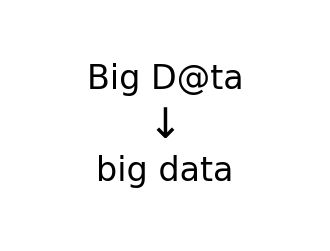

In [46]:
demo_clean("Big D@ta")

### Example: Remove non letters
This step is used to remove symbols that are used to space to avoid cuss word detection.

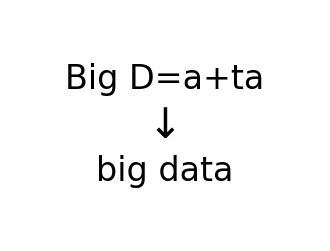

In [47]:
demo_clean("Big D=a+ta")

### Example: Un-Flood
This step is to remove floods (Floods are basically repeating characters that are spammed to occupy space).

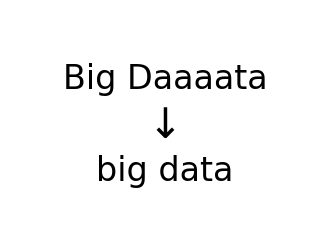

In [48]:
demo_clean("Big Daaaata")

## Detection logic

In [49]:
# Detect cuss words
def detect_cuss(text):
    words = clean_text(text).split()
    
    for word in words:
        # skip short word because a small change can impact the  similarity significantly
        if len(word) <= 3:
            continue
        
        for bad in cuss_words:
            # skip if the first letter is not listed
            if word[0] != bad[0]:
                continue
            
            # if the length of the word is diffrent,
            if abs(len(word) - len(bad)) > 2:
                continue
            
            dist = Levenshtein.distance(word, bad)
            similarity = 1 - (dist / max(len(word), len(bad)))
            
            # Filter low similarity
            if similarity >= 0.85:
                return True, word, bad, dist
    
    return False, None, None, None

## Calculate the similarity

In [50]:
results = [] # for da return

for _, row in df.iterrows():
    detected, word, base, dist = detect_cuss(row["text"])
    
    results.append({
        "text": row["text"][:50],
        "detected": detected,
        "matched_word": word,
        "base_word": base,
        "distance": dist
    })

result_df = pd.DataFrame(results)

In [51]:
print(result_df.head(10))

                                                text  detected matched_word  \
0  Elon Musk is a piece of shit, greedy capitalis...      True         shit   
1  The senile credit card shrill from Delaware ne...     False          NaN   
2  He does that a lot -- makes everyone look good...      True     bullshit   
3                                         F*ck Lizzo     False          NaN   
4  Epstein and trump were best buds!!! Pedophiles...     False          NaN   
5  WHY IN THE HELL\n Are we sending Biden out to ...      True         hell   
6  Now we all know this is just another fantasy w...     False          NaN   
7  WE MANAGED TO FIND AN ASSHOLE WHO'S A BIGGER S...      True      asshole   
8  After all the leftist said and did to DT, you ...     False          NaN   
9  This is for all you Crybaby Transpo-People , N...      True        sissy   

   base_word  distance  
0       shit       0.0  
1        NaN       NaN  
2  bull shit       1.0  
3        NaN       NaN  
4    